# CSF/blood validation analysis

In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(future)
  library(tidyverse)
  library(ggExtra)
  library(patchwork)
  library(cowplot)
  library(ComplexHeatmap)
})

In [2]:
options(future.globals.maxSize = 1000000 * 1024^2, hpc.ncpus = 16)
plan(multicore, workers = getOption("hpc.ncpus", 1))

# Helper functions

In [3]:
source("../scripts/plotting.R")

# Load data

### Filtered dataset

QS object generated by running notebooks in `03_annotate`

In [ ]:
seu <- qs::qread(file = "../data/processed/external/cantoni/annotated/cantoni_untreated_ms_hc_filtered.qs", nthreads = getOption("hpc.ncpus", 1))

### Program scores

In [5]:
gep.usage <- set_names(c("T")) %>%
  map(
    .f = function(x) {
      mat <- read_tsv(
        file = glue::glue("../results/tables/external/cantoni/gep/{x}/finalised/usage.tsv"),
        col_names = TRUE,
        show_col_types = FALSE
      ) %>%
        column_to_rownames("...1") %>%
        as.matrix()
      labels <- yaml::read_yaml(glue::glue("../results/tables/external/cantoni/gep/{x}/finalised/module_labels.yaml"))
      colnames(mat) <- labels[colnames(mat)]
      return(t(mat))
    }
  )

New names:
* `` -> `...1`


# Compute UMAP

In [10]:
seu <- RunUMAP(
  seu,
  reduction = "integrated.rna",
  dims = 1:50,
  metric = "cosine",
  n.neighbors = 30L,
  min.dist = 0.3,
  spread = 1,
  n.epochs = 200L
)

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"
22:31:20 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

22:31:20 Read 178027 rows and found 50 numeric columns

22:31:20 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

22:31:20 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

22:31:36 Writing NN index file to

# Custom colour palettes

### Clusters

In [5]:
cluster.main.pal <- c(
  B = pals::brewer.reds(100)[90],
  DC = pals::brewer.greys(100)[90],
  Mono = pals::brewer.purples(100)[90],
  ILC = pals::brewer.oranges(100)[50],
  NK = pals::brewer.blues(100)[90],
  T = pals::brewer.greens(100)[90]
)

In [6]:
cluster.coarse.pal <- c(
  B_naive = pals::brewer.reds(5)[3],
  B_memory = pals::brewer.reds(5)[2],
  B_plasma = pals::brewer.reds(5)[4],
  DC_AXL_SIGLEC6 = pals::brewer.greys(5)[3],
  DC_conventional = pals::brewer.greys(5)[2],
  DC_plasmacytoid = pals::brewer.greys(5)[4],
  ILC = pals::brewer.oranges(100)[50],
  Mono_CD14 = pals::brewer.purples(5)[2],
  Mono_CD16 = pals::brewer.purples(5)[4],
  NK_CD56dim = pals::brewer.blues(5)[4],
  NK_CD56bright = pals::brewer.blues(5)[2],
  T_CD4_naive = pals::brewer.greens(10)[2],
  T_CD4_memory = pals::brewer.greens(10)[7],
  T_regulatory_naive = pals::brewer.greens(10)[5],
  T_regulatory_memory = pals::brewer.greens(10)[9],
  T_CD8_naive = pals::brewer.greens(10)[10],
  T_CD8_memory = pals::brewer.greens(10)[6],
  T_MAIT = pals::brewer.greens(10)[4],
  T_GD = pals::brewer.greens(10)[8],
  T_DN = pals::brewer.greens(10)[3]
)

In [7]:
cluster.pal <- c(cluster.main.pal, cluster.coarse.pal)

# Visualise integration

In [8]:
seu$author_clean <- case_match(
  as.character(seu$author),
  "unpublished" ~ "Cantoni et al.",
  "Esaulova et al.," ~ "Essaulova et al.",
  "Pappalardo JL, et al" ~ "Pappalardo et al.",
  "Ramesh A, et al" ~ "Ramesh et al.",
  "Schafflick D, et al" ~ "Schafflick et al."
)

Inferred data type as 'discrete'. To override, set type explicitly.



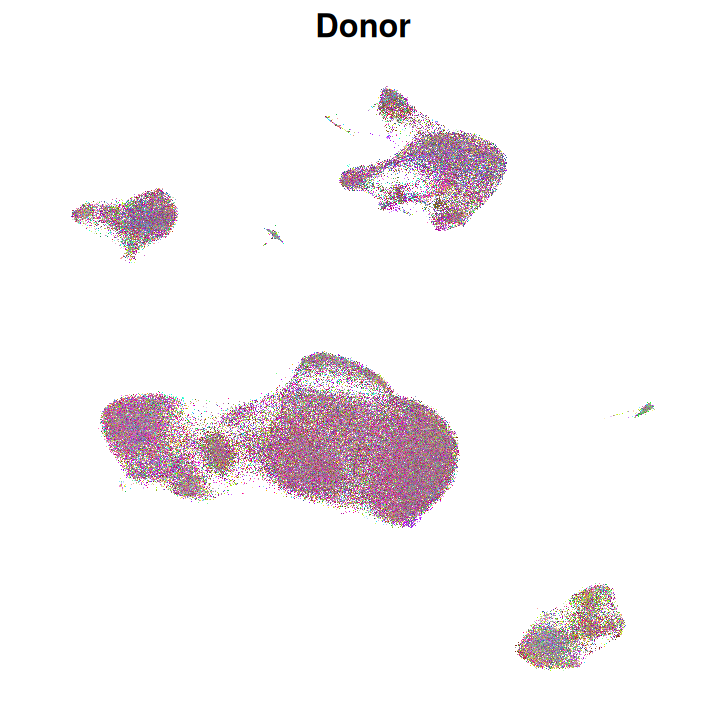

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

plot <- embedding.plot(
  seu,
  colour = "sample_pair",
  cmap = pals::polychrome(30) |> set_names(sort(unique(seu$sample_pair))),
  labs = list(title = "Donor"),
  show.legend = FALSE,
  rasterise = TRUE,
  size.adj = 2,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  filename = "../results/plots/cantoni_untreated_ms_hc_all_donor_umap.pdf",
  plot = plot,
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

Inferred data type as 'discrete'. To override, set type explicitly.



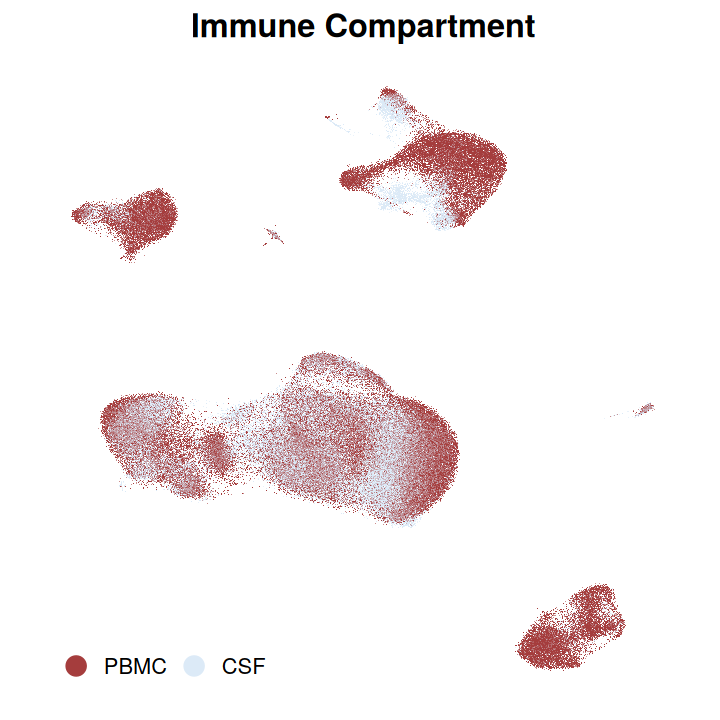

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(seu, vars = c("umap_1", "umap_2", "organ")) %>%
  mutate(organ = factor(organ, levels = c("PBMC", "CSF")))

plot <- embedding.plot(
  data,
  colour = "organ",
  cmap = c(PBMC = "#a53d3d", CSF = "#dceaf7"),
  labs = list(title = "Immune Compartment", colour = NULL),
  show.legend = TRUE,
  rasterise = TRUE,
  size.adj = 2,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  guides(colour = guide_legend(override.aes = list(size = 5), nrow = 1)) +
  inset.legend(location = "bottomleft") +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  filename = "../results/plots/cantoni_untreated_ms_hc_all_immune_compartment_umap.pdf",
  plot = plot,
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

Inferred data type as 'discrete'. To override, set type explicitly.



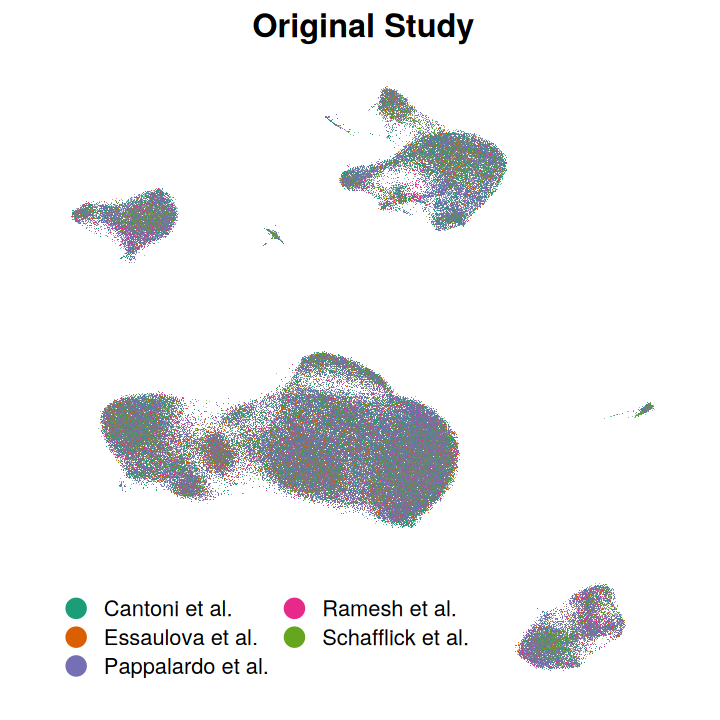

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

plot <- embedding.plot(
  seu,
  colour = "author_clean",
  cmap = pals::brewer.dark2(5) |> set_names(sort(unique(seu$author_clean))),
  labs = list(title = "Original Study", colour = NULL),
  show.legend = TRUE,
  rasterise = TRUE,
  size.adj = 2,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  guides(colour = guide_legend(override.aes = list(size = 5), nrow = 3)) +
  inset.legend(location = "bottomleft") +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  filename = "../results/plots/cantoni_untreated_ms_hc_all_study_umap.pdf",
  plot = plot,
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

Inferred data type as 'discrete'. To override, set type explicitly.



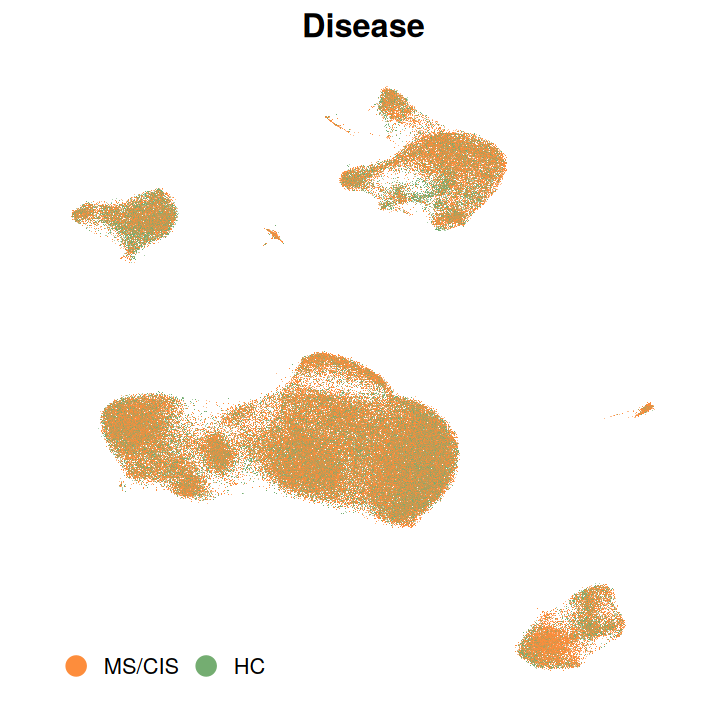

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(seu, vars = c("umap_1", "umap_2", "disease")) %>%
  mutate(disease = if_else(disease != "HC", "MS/CIS", "HC") |> factor(levels = c("MS/CIS", "HC")))

plot <- embedding.plot(
  data,
  colour = "disease",
  cmap = c(`MS/CIS` = "#FD8D3C", HC = "#74ad71"),
  labs = list(title = "Disease", colour = NULL),
  show.legend = TRUE,
  rasterise = TRUE,
  size.adj = 2,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  guides(colour = guide_legend(override.aes = list(size = 5), nrow = 1)) +
  inset.legend(location = "bottomleft") +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  filename = "../results/plots/cantoni_untreated_ms_hc_all_disease_umap.pdf",
  plot = plot,
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Visualise cell types

Warning message:
"There were 6 warnings in `reframe()`.
The first warning was:
i In argument: `{ ... }`.
i In group 3: `cluster_coarse = B_plasma`.
Caused by warning in `KernSmooth::bkde2D()`:
! Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'
i Run `dplyr::last_dplyr_warnings()` to see the 5 remaining warnings."
Inferred data type as 'discrete'. To override, set type explicitly.



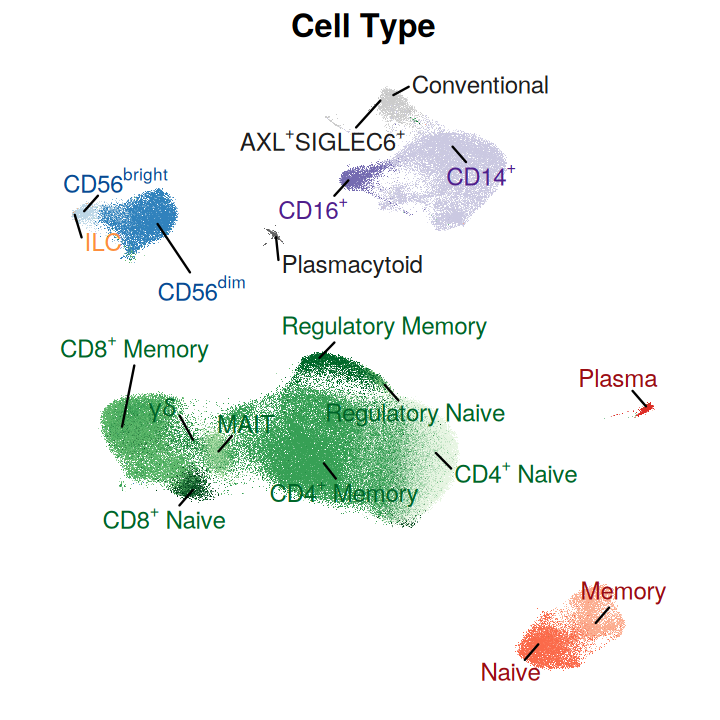

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(seu, vars = c("umap_1", "umap_2", "cluster_coarse", "cluster_main"))
labels <- data %>%
  group_by(cluster_coarse) %>%
  summarise(cluster_main = first(cluster_main)) %>%
  left_join(calculate.centroid.density(data, group.var = "cluster_coarse", x.var = "umap_1", y.var = "umap_2"), by = "cluster_coarse") %>%
  mutate(
    cluster_coarse = case_match(
      as.character(cluster_coarse),
      "B_naive" ~ "Naive",
      "B_memory" ~ "Memory",
      "B_plasma" ~ "Plasma",
      "DC_AXL_SIGLEC6" ~ "AXL^'+'*SIGLEC6^'+'",
      "DC_conventional" ~ "Conventional",
      "DC_plasmacytoid" ~ "Plasmacytoid",
      "ILC" ~ "ILC",
      "Mono_CD14" ~ "CD14^'+'",
      "Mono_CD16" ~ "CD16^'+'",
      "NK_CD56dim" ~ "CD56^dim",
      "NK_CD56bright" ~ "CD56^bright",
      "T_CD4_naive" ~ "CD4^'+'~Naive",
      "T_CD4_memory" ~ "CD4^'+'~Memory",
      "T_regulatory_naive" ~ "Regulatory~Naive",
      "T_regulatory_memory" ~ "Regulatory~Memory",
      "T_CD8_naive" ~ "CD8^'+'~Naive",
      "T_CD8_memory" ~ "CD8^'+'~Memory",
      "T_MAIT" ~ "MAIT",
      "T_GD" ~ "gamma*delta",
      "T_DN" ~ "CD4^'-'*CD8^'-'"
    )
  )

plot <- embedding.plot(data, colour = "cluster_coarse", cmap = cluster.pal, labs = list(title = "Cell Type", colour = NULL), show.legend = FALSE, rasterise = TRUE, size.adj = 2, alpha = 1, pixels = c(2048, 2048)) +
  ggrepel::geom_text_repel(
    data = labels,
    mapping = aes(x = x, y = y, colour = cluster_main, label = cluster_coarse),
    segment.colour = "black",
    box.padding = 0.75,
    size = 5,
    max.overlaps = Inf,
    min.segment.length = 0,
    seed = 42,
    parse = TRUE,
    show.legend = FALSE
  ) +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  plot = plot,
  filename = "../results/plots/cantoni_untreated_ms_hc_all_cell_type_umap.pdf",
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Subset to T cells

In [9]:
# Subset to T cells only
sub <- subset(seu, subset = cluster_main == "T")
Idents(sub) <- "cluster_coarse"

In [10]:
sub[["GEP"]] <- CreateAssayObject(data = gep.usage[["T"]])

Warning message:
"Layer counts isn't present in the assay object; returning NULL"


# Cross-compartment T~c~1-TH signature comparison

In [12]:
chosen.gep <- Features(sub[["GEP"]])[c(13, 20, 30)]
chosen.gep

[1] "Th1-like (CXCR3/CCL5/ITGA4)"             
[2] "Cytotoxic Inflammatory (GZMK/EOMES/IFNG)"
[3] "Activation Signalling (IER2/CD69/CD83)"

In [13]:
sub$program_score <- apply(GetAssayData(sub, assay = "GEP", layer = "data")[chosen.gep, ], 2, sum)

In [14]:
data <- FetchData(sub, vars = c("sample", "sample_pair", "disease", "organ", "age", "sex", "cluster_coarse", "program_score")) %>%
  mutate(
    disease = factor(if_else(disease == "HC", "HC", "MS/CIS"), levels = c("MS/CIS", "HC")),
    organ = factor(organ, levels = c("PBMC", "CSF"))
  ) %>% 
  filter(cluster_coarse %in% c("T_CD4_memory", "T_CD8_memory"))

data.summary <- data %>%
  group_by(disease, organ, sample_pair, sample) %>%
  summarise(
    program_score = mean(program_score, na.rm = TRUE),
    sample_pair = first(sample_pair),
    age = first(age),
    sex = first(sex),
    .groups = "drop"
  )

In [15]:
model <- lmerTest::lmer(
  program_score ~ disease * organ + age + sex + (1 | sample_pair),
  data = data.summary
)

In [16]:
emm <- emmeans::emmeans(model, ~ disease * organ, lmer.df = "Satterthwaite")

contrasts <- list(
  "HC CSF vs PBMC" = c(0, -1, 0, 1),
  "MS/CIS CSF vs PBMC" = c(-1, 0, 1, 0)
)

stats <- emmeans::contrast(emm, method = contrasts, adjust = "none") %>%
  summary(infer = TRUE) %>%
  mutate(
    p.adj = p.adjust(p.value, method = "BH"),
    significance = case_when(
      p.adj < 0.001 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n***"),
      p.adj < 0.01 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n**"),
      p.adj < 0.05 ~ glue::glue("p = {round(p.adj, 3)}\n*"),
      p.adj < 0.1 ~ glue::glue("p = {round(p.adj, 3)}\n."),
      TRUE ~ glue::glue("p = {round(p.adj, 3)}\nns")
    ),
    disease = str_split_i(contrast, " ", 1)
  ) %>%
  rowwise() %>%
  mutate(
    group1 = str_trim(str_split_i(gsub(disease, "", contrast), " vs ", 1)),
    group2 = str_trim(str_split_i(gsub(disease, "", contrast), " vs ", 2))
  ) %>%
  ungroup() %>%
  mutate(
    y.position = 0.28
  )

In [17]:
stats

contrast,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,p.adj,significance,disease,group1,group2,y.position
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<glue>,<chr>,<chr>,<chr>,<dbl>
HC CSF vs PBMC,0.001228486,0.01566017,25.97990,-0.03096267,0.03341965,0.07844654,0.9380739505,0.9380739505,p = 0.938 ns,HC,CSF,PBMC,0.28
MS/CIS CSF vs PBMC,0.043835881,0.01084287,27.60135,0.02161081,0.06606095,4.04283023,0.0003825053,0.0007650106,p = 7.65e-04 ***,MS/CIS,CSF,PBMC,0.28


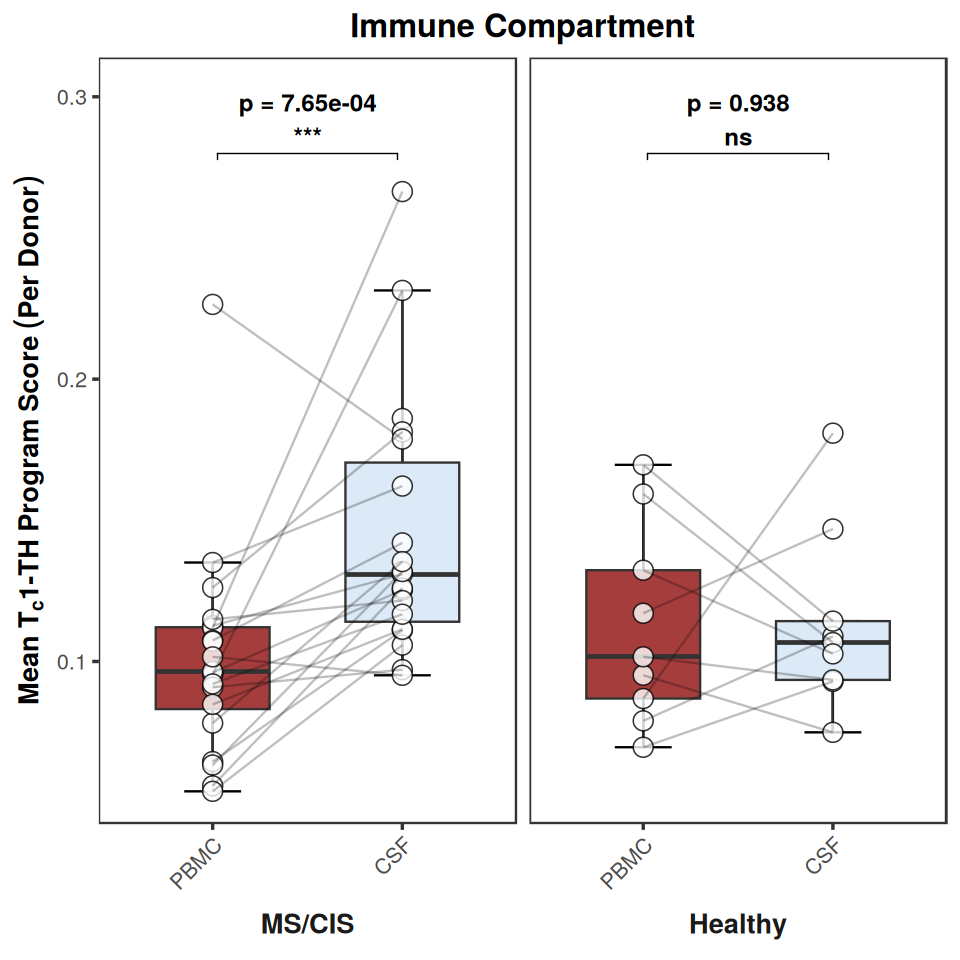

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 8)

ggplot(data = data.summary, mapping = aes(x = organ, y = program_score)) +
  stat_boxplot(
    geom = "errorbar",
    width = 0.3
  ) +
  geom_boxplot(
    mapping = aes(fill = organ),
    width = 0.6,
    outlier.shape = NA,
    alpha = 1,
    size = 0.5
  ) +
  geom_point(
    size = 5,
    alpha = 0.8,
    stroke = 0.5,
    shape = 21,
    fill = "white",
    color = "black"
  ) +
  geom_line(
    mapping = aes(group = sample_pair),
    color = "black",
    alpha = 0.25,
    linewidth = 0.5
  ) +
  ggpubr::stat_pvalue_manual(
    data = stats,
    label = "significance",
    fontface = "bold",
    size = 5,
    tip.length = 0.01,
    bracket.shorten = -0.05
  ) +
  facet_wrap(~ factor(case_match(disease, "HC" ~ "Healthy", .default = disease), levels = c("MS/CIS", "Healthy")), strip.position = "bottom") +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
  scale_fill_manual(values = c(PBMC = "#a53d3d", CSF = "#dceaf7")) +
  labs(
    title = "Immune Compartment",
    subtitle = NULL,
    x = NULL,
    y = expression(bold(Mean ~ T[c] * "1-" * TH ~ Program ~ Score ~ (Per ~ Donor)))
  ) +
  theme_custom() +
  theme(
    strip.background = element_blank(),
    strip.text = element_text(size = 16, face = "bold"),
    strip.placement = "outside",
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none"
  )

ggsave(
  filename = "../results/plots/cantoni_untreated_ms_hc_tc1th_compartment_boxplot.pdf",
  width = 8,
  height = 8,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

In [19]:
data.ratio <- data.summary %>%
  pivot_wider(id_cols = c("sample_pair", "disease", "age", "sex"), names_from = "organ", values_from = "program_score") %>%
  drop_na() %>%
  mutate(log_ratio = log2(CSF / PBMC))

In [20]:
model <- lm(log_ratio ~ disease + age + sex, data = data.ratio)

In [21]:
emm <- emmeans::emmeans(model, ~disease)

contrasts <- list(
  "MS/CIS vs HC" = c(-1, 1)
)

stats <- emmeans::contrast(emm, method = contrasts, adjust = "none") %>%
  summary(infer = TRUE) %>%
  mutate(
    p.adj = p.adjust(p.value, method = "BH"),
    significance = case_when(
      p.adj < 0.001 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n***"),
      p.adj < 0.01 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n**"),
      p.adj < 0.05 ~ glue::glue("p = {round(p.adj, 3)}\n*"),
      p.adj < 0.1 ~ glue::glue("p = {round(p.adj, 3)}\n."),
      TRUE ~ glue::glue("p = {round(p.adj, 3)}\nns")
    ),
  ) %>%
  rowwise() %>%
  mutate(
    group1 = str_trim(str_split_i(contrast, " vs ", 1)),
    group2 = str_trim(str_split_i(contrast, " vs ", 2))
  ) %>%
  ungroup() %>%
  mutate(
    y.position = 1.5
  )

In [22]:
stats

contrast,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,p.adj,significance,group1,group2,y.position
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<glue>,<chr>,<chr>,<dbl>
MS/CIS vs HC,-0.5781178,0.2129481,23,-1.018635,-0.137601,-2.714829,0.0123557,0.0123557,p = 0.012 *,MS/CIS,HC,1.5


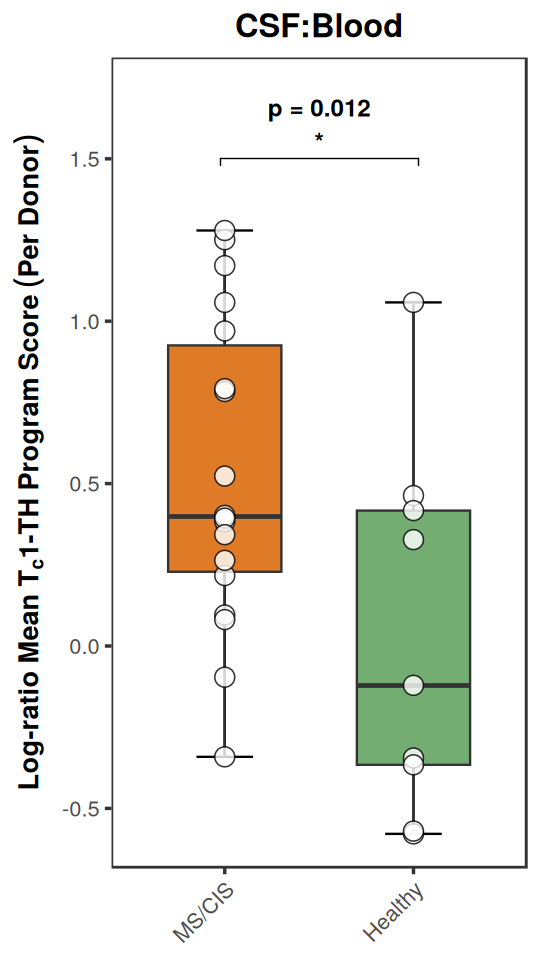

In [ ]:
options(repr.plot.width = 4.5, repr.plot.height = 8)

ggplot(data = data.ratio, mapping = aes(x = disease, y = log_ratio)) +
  stat_boxplot(
    geom = "errorbar",
    width = 0.3
  ) +
  geom_boxplot(
    mapping = aes(fill = disease),
    width = 0.6,
    outlier.shape = NA,
    alpha = 1,
    size = 0.5
  ) +
  geom_point(
    size = 5,
    alpha = 0.8,
    stroke = 0.5,
    shape = 21,
    fill = "white",
    color = "black"
  ) +
  ggpubr::stat_pvalue_manual(
    data = stats,
    label = "significance",
    fontface = "bold",
    size = 5,
    tip.length = 0.01,
    bracket.shorten = -0.05
  ) +
  scale_x_discrete(labels = c("MS/CIS" = "MS/CIS", "HC" = "Healthy")) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
  scale_fill_manual(values = c(`MS/CIS` = "#df7b26", HC = "#74ad71")) +
  labs(
    title = "CSF:Blood",
    x = NULL,
    y = expression(bold(Log*'-'*ratio~Mean ~ T[c] * "1-" * TH ~ Program ~ Score ~ (Per ~ Donor)))
  ) +
  theme_custom() +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none"
  )

ggsave(
  filename = "../results/plots/cantoni_untreated_ms_hc_tc1th_ratio_boxplot.pdf",
  width = 4.5,
  height = 8,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)


# Session info

In [7]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /ceph/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
[1] C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] ComplexHeatmap_2.18.0 cowplot_1.1.3         patchwork_1.3.0      
 [4] ggExtra_0.11.0        lubridate_1.9.3       forcats_1.0.0        
 [7] stringr_1.5.1         dplyr_1.1.4           purrr_1.0.2          
[10] readr_2.1.5           tidyr_1.3.1           tibble_3.2.1         
[13] ggplot2_3.5.1         tidyverse_2.0.0       future_1.34.0        
[16] Seurat_5.1.0          SeuratObject_5.0.2    sp_2.1-4             

loaded via a namespace (and not attached):
  [1] RcppAnnoy_0.0.22       splines_4.3.3          later_1.3.2         